# VRT SPC report

Report-style notebook for SPC contrasts in the VRT dataset.
Default response mask excludes cued responses (`cue_clips == 0`).


In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.spc import plot_spc
from jaxcmr.helpers import find_project_root, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
run_tag = "VRT_SPC"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
use_first_phase_only = True
size = 3


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]
intentionality = data["intentionality"]


def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)

first_phase_mask = trial_mask(((task == 1) & (intentionality == 1)) | ((task == 2) & (intentionality == 2)))
phase_label = "First Phase" if use_first_phase_only else "All Phases"


def phase_mask(mask):
    base = trial_mask(mask)
    return base & first_phase_mask if use_first_phase_only else base


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def plot_contrast(masks, labels, contrast_name, axis=None, suffix=None):
    plot_spc(
        datasets=[data] * len(masks),
        trial_masks=masks,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
        size=size,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)


## Q1. Is SPC Different Between Involuntary And Voluntary Tasks?


Involuntary: trials=240, subjects=240
Voluntary: trials=240, subjects=240


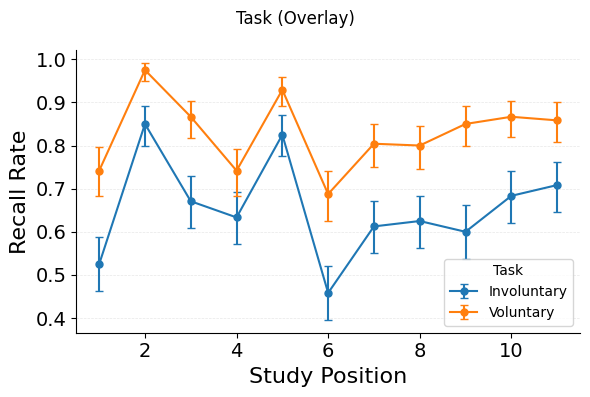

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Task", axis=ax)

fig.suptitle("Task (Overlay)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_overlay")


## Q2. What If We Only Look At The First Recall Trial After Each Study Phase?

Use `use_first_phase_only` (in the parameters cell) to toggle whether analyses after Q2 are restricted to first-phase trials. When True:
- intentionality == 1 (Involuntary-First) → task == 1 (Involuntary)
- intentionality == 2 (Voluntary-First) → task == 2 (Voluntary)

When False, analyses include both phases.


Matched-First: trials=240, subjects=240
Mismatched-First: trials=240, subjects=240


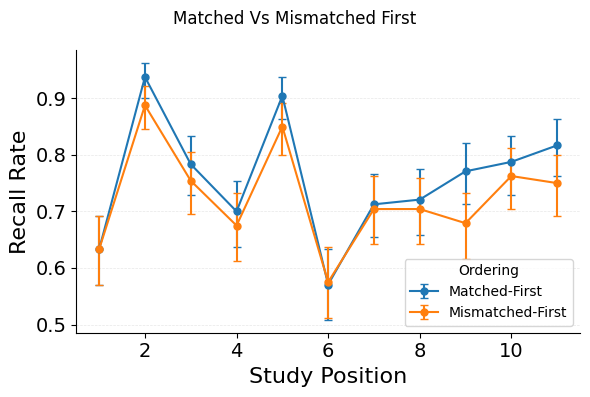

Involuntary-First: trials=120, subjects=120
Voluntary-First: trials=120, subjects=120


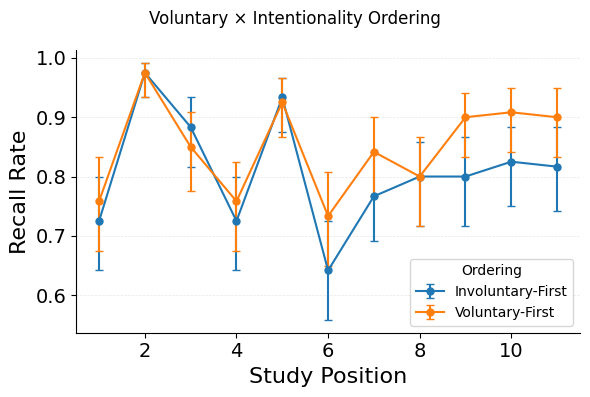

Involuntary-First: trials=120, subjects=120
Voluntary-First: trials=120, subjects=120


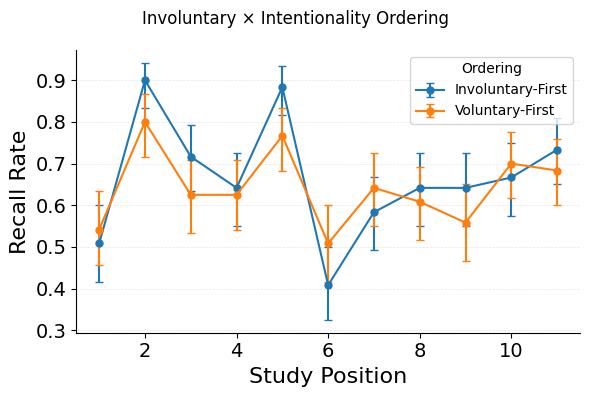

In [5]:
# Q2 Add-On: One-IV-At-A-Time Comparisons (Overlay)

# Matched-First vs Mismatched-First
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_matched = trial_mask(((task == 1) & (intentionality == 1)) | ((task == 2) & (intentionality == 2)))
mask_mismatched = trial_mask(((task == 1) & (intentionality == 2)) | ((task == 2) & (intentionality == 1)))

labels = ["Matched-First", "Mismatched-First"]
masks = [mask_matched, mask_mismatched]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Ordering", axis=ax)

fig.suptitle("Matched Vs Mismatched First")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_matched_mismatched")

# Voluntary Only: Intentionality Ordering
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_voluntary_involuntary_first = trial_mask((task == 2) & (intentionality == 1))
mask_voluntary_voluntary_first = trial_mask((task == 2) & (intentionality == 2))

labels = ["Involuntary-First", "Voluntary-First"]
masks = [mask_voluntary_involuntary_first, mask_voluntary_voluntary_first]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Ordering", axis=ax)

fig.suptitle("Voluntary × Intentionality Ordering")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_voluntary")

# Involuntary Only: Intentionality Ordering
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_involuntary_involuntary_first = trial_mask((task == 1) & (intentionality == 1))
mask_involuntary_voluntary_first = trial_mask((task == 1) & (intentionality == 2))

labels = ["Involuntary-First", "Voluntary-First"]
masks = [mask_involuntary_involuntary_first, mask_involuntary_voluntary_first]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Ordering", axis=ax)

fig.suptitle("Involuntary × Intentionality Ordering")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_involuntary")


## Q3. Task × Condition (Emotional Vs Neutral)


Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


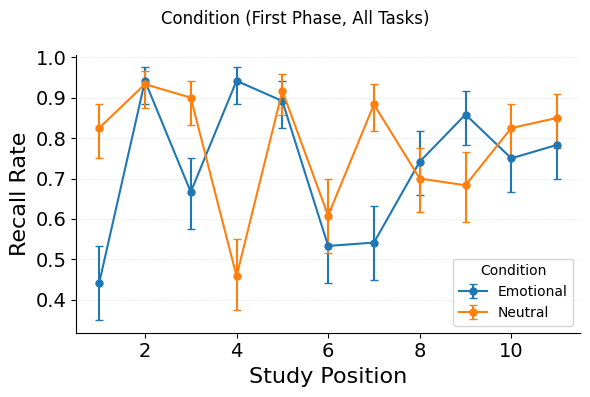

In [6]:
# Q3 Add-On: Condition (All Tasks) (Overlay)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_first_phase = first_phase_mask if use_first_phase_only else trial_mask(jnp.ones_like(task, dtype=bool))

mask_emotional = mask_first_phase & trial_mask(condition == 1)
mask_neutral = mask_first_phase & trial_mask(condition == 2)

labels = ["Emotional", "Neutral"]
masks = [mask_emotional, mask_neutral]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Condition", axis=ax)

fig.suptitle(f"Condition ({phase_label}, All Tasks)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_all_tasks")


## Q4. Task × Intervention (Podcast Vs Tetris)


Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


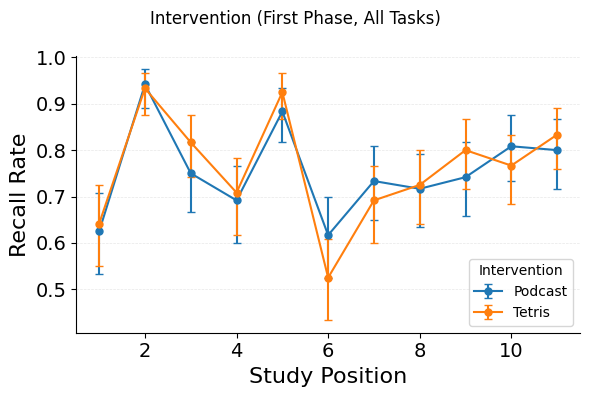

In [7]:
# Q4 Add-On: Intervention (All Tasks) (Overlay)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_first_phase = first_phase_mask if use_first_phase_only else trial_mask(jnp.ones_like(task, dtype=bool))

mask_podcast = mask_first_phase & trial_mask(intervention == 0)
mask_tetris = mask_first_phase & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention ({phase_label}, All Tasks)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_all_tasks")


## Q5. Task × Intervention × Condition


Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


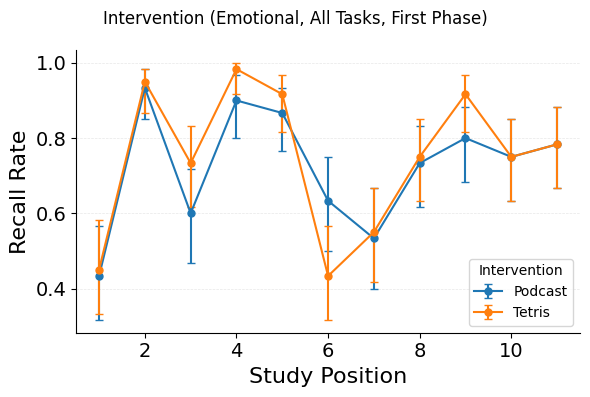

Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


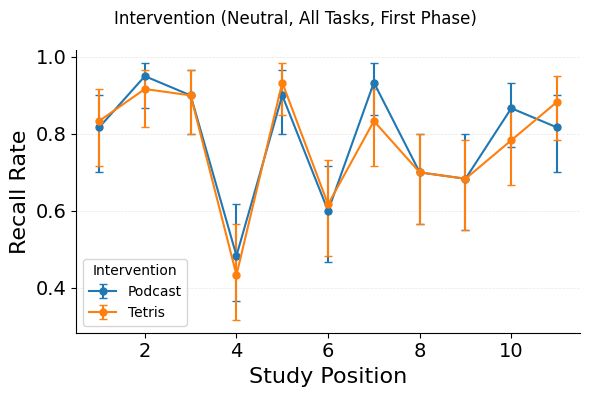

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


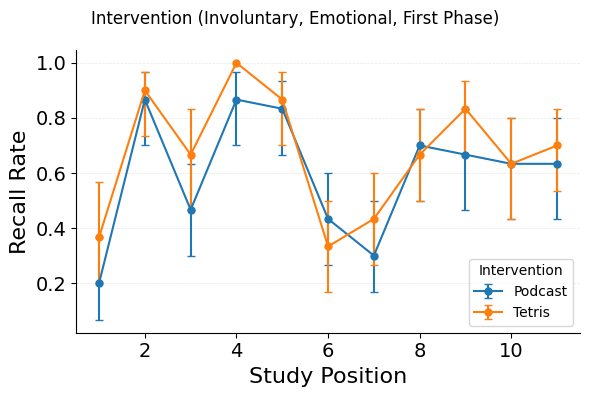

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


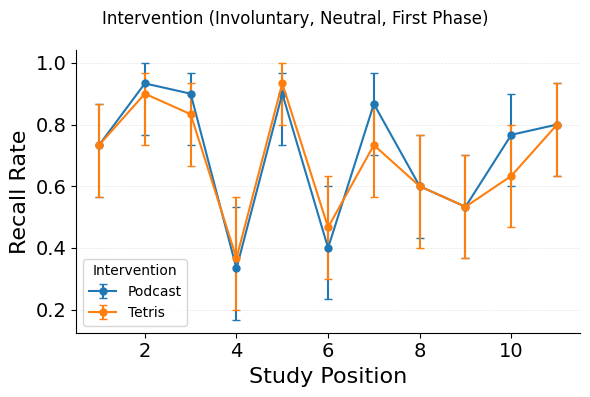

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


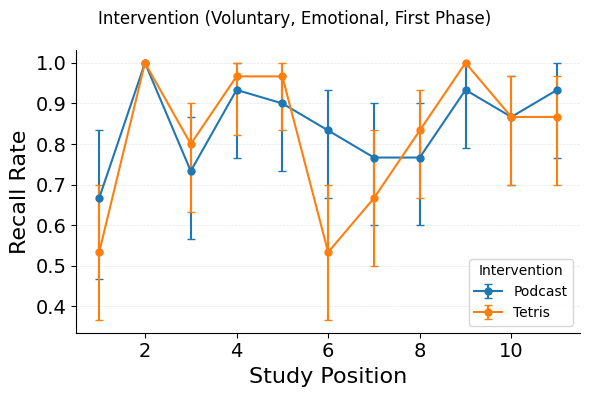

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


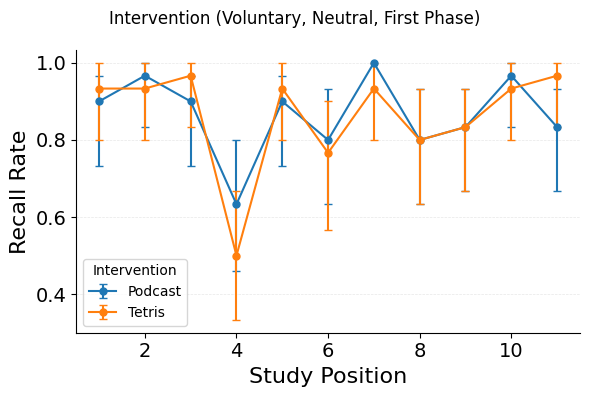

In [8]:
# Q5: Intervention Effects By Condition And Task (Overlay)

# All Tasks: Emotional
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_all = phase_mask(jnp.ones_like(task, dtype=bool))
mask_emotional = mask_all & trial_mask(condition == 1)

mask_podcast = mask_emotional & trial_mask(intervention == 0)
mask_tetris = mask_emotional & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention (Emotional, All Tasks, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_emotional_all")

# All Tasks: Neutral
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_neutral = mask_all & trial_mask(condition == 2)

mask_podcast = mask_neutral & trial_mask(intervention == 0)
mask_tetris = mask_neutral & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention (Neutral, All Tasks, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_neutral_all")

# Involuntary: Emotional
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_involuntary = phase_mask(task == 1)
mask_emotional = mask_involuntary & trial_mask(condition == 1)

mask_podcast = mask_emotional & trial_mask(intervention == 0)
mask_tetris = mask_emotional & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention (Involuntary, Emotional, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_involuntary_emotional")

# Involuntary: Neutral
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_neutral = mask_involuntary & trial_mask(condition == 2)

mask_podcast = mask_neutral & trial_mask(intervention == 0)
mask_tetris = mask_neutral & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention (Involuntary, Neutral, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_involuntary_neutral")

# Voluntary: Emotional
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_voluntary = phase_mask(task == 2)
mask_emotional = mask_voluntary & trial_mask(condition == 1)

mask_podcast = mask_emotional & trial_mask(intervention == 0)
mask_tetris = mask_emotional & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention (Voluntary, Emotional, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_voluntary_emotional")

# Voluntary: Neutral
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_neutral = mask_voluntary & trial_mask(condition == 2)

mask_podcast = mask_neutral & trial_mask(intervention == 0)
mask_tetris = mask_neutral & trial_mask(intervention == 1)

labels = ["Podcast", "Tetris"]
masks = [mask_podcast, mask_tetris]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name="Intervention", axis=ax)

fig.suptitle(f"Intervention (Voluntary, Neutral, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_voluntary_neutral")
